# Ejercicio 2 — Sueldos (regresión lineal con un valor atípico)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fcaceres-create/caece-aprendizaje-artificial-u3-datamining/blob/main/notebooks/02_sueldos_valores_atipicos.ipynb)

**Metodologías de Data Mining — Unidad 3**

Queremos explicar el **sueldo** (en miles) a partir de los años de **experiencia**, los años de
**estudio** y el **sexo**. Vamos a ver cómo **un solo caso atípico** puede arruinar el modelo, y cómo
detectarlo con residuos estudentizados, leverage y distancia de Cook.

## 1. Librerías y datos

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

URL_DATOS = "https://raw.githubusercontent.com/fcaceres-create/caece-aprendizaje-artificial-u3-datamining/main/notebooks/datos/"

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def verificar(nombre, obtenido, esperado, decimales=2):
    """Compara un resultado con el valor de referencia de la cátedra (redondeado a `decimales`)."""
    ok = abs(obtenido - esperado) <= 0.5 * 10 ** -decimales + 1e-9
    print(f"{'✔' if ok else '✘'} {nombre}: obtenido = {obtenido:.{decimales}f}   esperado = {esperado}")

In [2]:
df = pd.read_csv(URL_DATOS + "ejercicio2.csv")

# Alternativa: subir el Excel de la cátedra a Colab (ícono de carpeta, a la izquierda) y leer la hoja:
# df = pd.read_excel("EjerciciosRegresion.xlsx", sheet_name="Ejercicio2")

df.index += 1  # numeramos las filas desde 1, como en el Excel
df["Sexo_M"] = (df["Sexo"] == "M").astype(int)  # ficticia: 1 = masculino, 0 = femenino
df

,Sueldo,Experiencia,Estudios,Sexo,Sexo_M
1,2745,5.5000,4.0000,F,0
2,3025,9.0000,4.0000,M,1
3,2945,4.0000,5.0000,F,0
4,2950,8.0000,4.0000,M,1
5,2875,9.5000,5.0000,M,1
6,2775,3.0000,4.0000,F,0
7,2800,7.0000,3.0000,F,0
8,2635,1.5000,4.5000,F,0
9,3250,8.5000,5.0000,M,1
10,3000,7.5000,6.0000,F,0


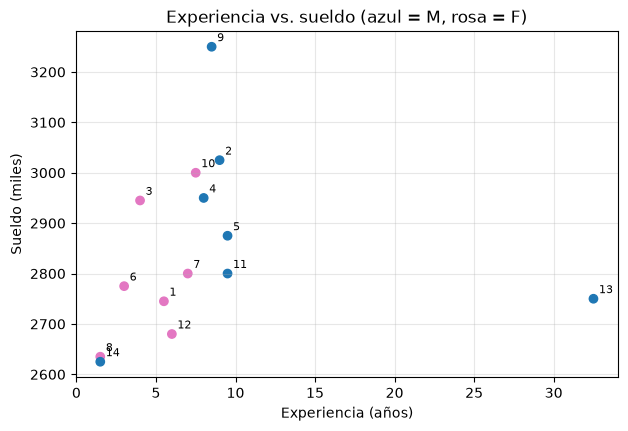

In [3]:
colores = df["Sexo"].map({"M": "tab:blue", "F": "tab:pink"})
plt.scatter(df["Experiencia"], df["Sueldo"], c=colores)
for i, fila in df.iterrows():
    plt.annotate(str(i), (fila["Experiencia"], fila["Sueldo"]), textcoords="offset points", xytext=(4, 4), fontsize=8)
plt.xlabel("Experiencia (años)")
plt.ylabel("Sueldo (miles)")
plt.title("Experiencia vs. sueldo (azul = M, rosa = F)")
plt.show()

Hay un caso que llama la atención: la **fila 13**, con **32,5 años de experiencia**, muy lejos del resto
(todos tienen menos de 10 años).

## 2. Modelo con los 14 casos

In [4]:
formula = "Sueldo ~ Experiencia + Estudios + Sexo_M"
m_todos = smf.ols(formula, data=df).fit()
print(m_todos.summary())

                            OLS Regression Results                            
Dep. Variable:                 Sueldo   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     1.268
Date:                Mon, 28 Sep 2026   Prob (F-statistic):              0.338
Time:                        09:36:33   Log-Likelihood:                -89.254
No. Observations:                  14   AIC:                             186.5
Df Residuals:                      10   BIC:                             189.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2530.2598    186.346     13.578      

In [5]:
verificar("R² (14 casos)", m_todos.rsquared, 0.276, 3)
verificar("p-valor del modelo (14 casos)", m_todos.f_pvalue, 0.338, 3)

✔ R² (14 casos): obtenido = 0.276   esperado = 0.276
✔ p-valor del modelo (14 casos): obtenido = 0.338   esperado = 0.338


Con todos los datos el modelo **no sirve**: explica solo el 27,6 % de la variabilidad y el test F no es
significativo (p = 0,338). Incluso la experiencia aparece con coeficiente casi nulo.

## 3. Detección de atípicos e influyentes

| Medida | Qué mide | Criterio usado |
|---|---|---|
| Residuo estudentizado (externo) | Qué tan mal predice el modelo ese caso | \|r\| > 2 |
| Leverage ($h_{ii}$) | Qué tan extremo es el caso en las X | $h > 2p/n$ |
| Distancia de Cook | Cuánto cambian los coeficientes si se saca el caso | $D > 4/n$ |

In [6]:
infl = m_todos.get_influence()
n, p = int(m_todos.nobs), len(m_todos.params)
lim_res, lim_lev, lim_cook = 2, 2 * p / n, 4 / n

diag = pd.DataFrame({
    "Experiencia": df["Experiencia"],
    "Sueldo": df["Sueldo"],
    "Residuo": m_todos.resid,
    "Res. estudentizado": infl.resid_studentized_external,
    "Leverage": infl.hat_matrix_diag,
    "Cook": infl.cooks_distance[0],
})
diag["Criterios superados"] = [
    ", ".join(c for c, ok in [
        ("residuo", abs(r) > lim_res),
        ("leverage", h > lim_lev),
        ("Cook", d > lim_cook),
    ] if ok) or "—"
    for r, h, d in zip(diag["Res. estudentizado"], diag["Leverage"], diag["Cook"])
]
print(f"Límites: |residuo| > {lim_res}, leverage > {lim_lev:.3f}, Cook > {lim_cook:.3f}\n")
diag

Límites: |residuo| > 2, leverage > 0.571, Cook > 0.286



,Experiencia,Sueldo,Residuo,Res. estudentizado,Leverage,Cook,Criterios superados
1,5.5000,2745,-47.0697,-0.2884,0.1437,0.0038,—
2,9.0000,3025,131.9891,0.8398,0.1516,0.0325,—
3,4.0000,2945,85.7693,0.5487,0.1958,0.0197,—
4,8.0000,2950,56.3948,0.3498,0.1607,0.0064,—
5,9.5000,2875,-83.9834,-0.5377,0.1981,0.0192,—
6,3.0000,2775,-18.5554,-0.1136,0.1496,0.0006,—
7,7.0000,2800,75.0913,0.4851,0.2169,0.0176,—
8,1.5000,2635,-192.5816,-1.3015,0.1714,0.0819,—
9,8.5000,3250,290.4224,2.3238,0.2040,0.2403,residuo
10,7.5000,3000,76.5796,0.5626,0.3892,0.0541,—


Casos influyentes (Cook > 4/n): [13, 14]
Caso más influyente: 13 (Cook = 11.85)


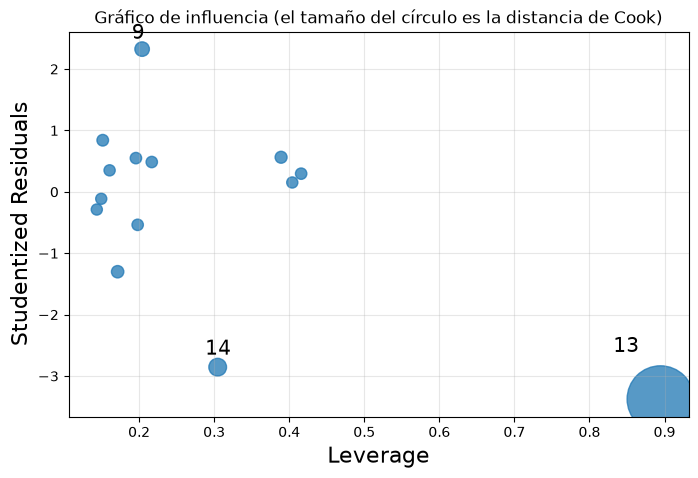

In [7]:
atipicos = diag.index[diag["Cook"] > lim_cook]
print("Casos influyentes (Cook > 4/n):", list(atipicos))
print("Caso más influyente:", diag["Cook"].idxmax(), f"(Cook = {diag['Cook'].max():.2f})")

fig, ax = plt.subplots(figsize=(8, 5))
sm.graphics.influence_plot(m_todos, ax=ax, criterion="cooks")
ax.set_title("Gráfico de influencia (el tamaño del círculo es la distancia de Cook)")
plt.show()

La **fila 13** (Experiencia = 32,5) supera los tres criterios: tiene un leverage altísimo (0,89) y una
distancia de Cook de 11,8, mucho mayor que 1. Es un caso **atípico e influyente**: arrastra la recta hacia él.

## 4. Modelo sin la fila con Experiencia = 32,5

In [8]:
df_sin = df[df["Experiencia"] != 32.5]
m_sin = smf.ols(formula, data=df_sin).fit()
print(m_sin.summary())

                            OLS Regression Results                            
Dep. Variable:                 Sueldo   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     6.142
Date:                Mon, 28 Sep 2026   Prob (F-statistic):             0.0147
Time:                        09:36:33   Log-Likelihood:                -78.042
No. Observations:                  13   AIC:                             164.1
Df Residuals:                       9   BIC:                             166.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    2257.5751    153.459     14.711      

In [9]:
b = m_sin.params
print(f"Sueldo = {b['Intercept']:.2f} {b['Experiencia']:+.2f}·Exp {b['Estudios']:+.2f}·Est {b['Sexo_M']:+.2f}·Sexo\n")

verificar("Constante", b["Intercept"], 2257.58)
verificar("Experiencia", b["Experiencia"], 42.66)
verificar("Estudios", b["Estudios"], 80.88)
verificar("Sexo (M = 1)", b["Sexo_M"], 5.92)
verificar("R² sin el atípico", m_sin.rsquared, 0.672, 3)

Sueldo = 2257.58 +42.66·Exp +80.88·Est +5.92·Sexo

✔ Constante: obtenido = 2257.58   esperado = 2257.58
✔ Experiencia: obtenido = 42.66   esperado = 42.66
✔ Estudios: obtenido = 80.88   esperado = 80.88
✔ Sexo (M = 1): obtenido = 5.92   esperado = 5.92
✔ R² sin el atípico: obtenido = 0.672   esperado = 0.672


## 5. Comparación lado a lado

In [10]:
def resumen(m):
    datos = {f"B {k}": v for k, v in m.params.items()}
    datos.update({f"p {k}": v for k, v in m.pvalues.items()})
    datos.update({"n": m.nobs, "R²": m.rsquared, "R² ajustado": m.rsquared_adj, "p del modelo (F)": m.f_pvalue})
    return pd.Series(datos)


pd.DataFrame({"Con todos los datos": resumen(m_todos), "Sin el atípico": resumen(m_sin)})

,Con todos los datos,Sin el atípico
B Intercept,"2,530.2598","2,257.5751"
B Experiencia,-0.5943,42.6598
B Estudios,66.2696,80.8846
B Sexo_M,103.0211,5.9210
p Intercept,0.0000,0.0000
p Experiencia,0.9326,0.0124
p Estudios,0.1422,0.0226
p Sexo_M,0.3256,0.9392
n,14.0000,13.0000
R²,0.2755,0.6718


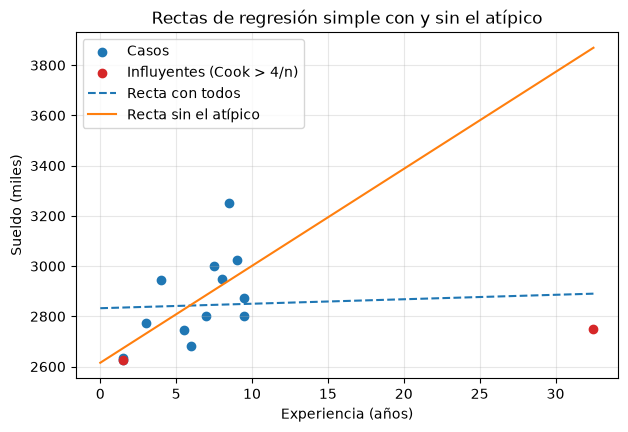

In [11]:
xs = np.linspace(0, df["Experiencia"].max(), 50)
plt.scatter(df_sin["Experiencia"], df_sin["Sueldo"], label="Casos")
plt.scatter(df.loc[atipicos, "Experiencia"], df.loc[atipicos, "Sueldo"], color="tab:red", label="Influyentes (Cook > 4/n)")
for datos, estilo, nombre in [(df, "--", "Recta con todos"), (df_sin, "-", "Recta sin el atípico")]:
    b1, b0 = np.polyfit(datos["Experiencia"], datos["Sueldo"], 1)
    plt.plot(xs, b0 + b1 * xs, estilo, label=nombre)
plt.xlabel("Experiencia (años)")
plt.ylabel("Sueldo (miles)")
plt.legend()
plt.title("Rectas de regresión simple con y sin el atípico")
plt.show()

Al sacar un solo caso el $R^2$ pasa de **0,276 a 0,672** y la experiencia se vuelve significativa:
cada año adicional suma unos 42,66 mil al sueldo.

## 6. Predicción paso a paso

In [12]:
experiencia, estudios, sexo = 4, 5, "M"
sexo_m = 1 if sexo == "M" else 0

b = m_sin.params
print(f"Sueldo = {b['Intercept']:.2f} + {b['Experiencia']:.2f}·Exp + {b['Estudios']:.2f}·Est + {b['Sexo_M']:.2f}·Sexo")
print(f"Sueldo = {b['Intercept']:.2f} + {b['Experiencia']:.2f}·{experiencia} + {b['Estudios']:.2f}·{estudios} + {b['Sexo_M']:.2f}·{sexo_m}")
print(f"Sueldo = {b['Intercept']:.2f} + {b['Experiencia'] * experiencia:.2f} + {b['Estudios'] * estudios:.2f} + {b['Sexo_M'] * sexo_m:.2f}")

caso = pd.DataFrame({"Experiencia": [experiencia], "Estudios": [estudios], "Sexo_M": [sexo_m]})
prediccion = m_sin.predict(caso).iloc[0]
print(f"Sueldo = {prediccion:.2f}\n")
verificar("Predicción (M, 4 años de experiencia, 5 de estudio)", prediccion, 2838.6, 1)

Sueldo = 2257.58 + 42.66·Exp + 80.88·Est + 5.92·Sexo
Sueldo = 2257.58 + 42.66·4 + 80.88·5 + 5.92·1
Sueldo = 2257.58 + 170.64 + 404.42 + 5.92
Sueldo = 2838.56

✔ Predicción (M, 4 años de experiencia, 5 de estudio): obtenido = 2838.6   esperado = 2838.6


## Conclusiones

- Con los 14 casos el modelo no es significativo por culpa de **un único caso influyente** (fila 13).
- Sin ese caso: **Sueldo = 2257,58 + 42,66·Exp + 80,88·Est + 5,92·Sexo**, con $R^2 = 0{,}672$.
- Antes de interpretar una regresión conviene revisar siempre los residuos, el leverage y la distancia de Cook.

👉 En la web interactiva (pestaña **2. Sueldos**) podés excluir puntos con un click y ver el cambio en vivo.